# Settings & Imports

In [4]:
import qeg_nmr_qua as qnmr

from functools import reduce
import json
import numpy as np
from math import factorial
import matplotlib.pyplot as plt
from pathlib import Path
from qualang_tools.units import unit
from scipy.optimize import curve_fit
from scipy.special import jn
import time


u = unit(coerce_to_integer=True)

In [10]:
# create base settings object for experiments
settings = qnmr.ExperimentSettings(
    n_avg=4,
    pulse_length=1.24 * u.us,
    pulse_amplitude=0.471,  # amplitude is 0.5*Vpp
    pulse_shape="square",
    pulse_rise_fall=0.0,  # 0% rise/fall time
    rotation_angle=141.7,  # degrees
    thermal_reset=4 * u.s,
    center_freq=282.1901 * u.MHz,
    offset_freq=16500 * u.Hz,
    readout_delay=20 * u.us,
    dwell_time=4 * u.us,
    readout_start=0 * u.us,
    readout_end=256 * u.us,
    save_dir=Path.home() / "Dropbox/QEG/NMR/RawData" / "floquet_expt/wei16"
)

cfg = qnmr.cfg_from_settings(settings)

# Moment Expansion Technique

In [8]:
# ---------- Basic spin-1/2 operators ----------
I = np.eye(2)
Ix = 0.5 * np.array([[0, 1], [1, 0]], dtype=complex)
Iy = 0.5 * np.array([[0, -1j], [1j, 0]], dtype=complex)
Iz = 0.5 * np.array([[1, 0], [0, -1]], dtype=complex)

Ip = Ix + 1j * Iy
Im = Ix - 1j * Iy


# ---------- Tensor product helper ----------
def kron_n(ops):
    return reduce(np.kron, ops)


# ---------- Build operator on full Hilbert space ----------
def op_on_spin(op, site, N):
    ops = [I] * N
    ops[site] = op
    return kron_n(ops)


# ---------- Build total Ix ----------
def total_Ix(N):
    return sum(op_on_spin(Ix, j, N) for j in range(N))


# ---------- Build dipolar Hamiltonian ----------
def build_H(N, D):
    H = 0
    for j in range(N):
        for k in range(j+1, N):
            H += D[j, k] * (
                op_on_spin(Iz, j, N) @ op_on_spin(Iz, k, N)
                - 0.25 * (
                    op_on_spin(Ip, j, N) @ op_on_spin(Im, k, N)
                    + op_on_spin(Im, j, N) @ op_on_spin(Ip, k, N)
                )
            )
    return H


# ---------- Commutator ----------
def comm(A, B):
    return A @ B - B @ A


# ---------- Nested commutator ----------
def nested_comm(H, A, n):
    result = A
    for _ in range(n):
        result = comm(H, result)
    return result


# ---------- Moment calculation ----------
def compute_moment(H, Ix_tot, n):
    """
    Computes M_{2n}
    """
    comm_term = nested_comm(H, Ix_tot, 2*n)
    numerator = np.trace(comm_term @ Ix_tot)
    denom = np.trace(Ix_tot @ Ix_tot)

    return (numerator / denom / factorial(2*n)).real


# ---------- Example usage ----------
N = 3  # number of spins

# Define dipolar couplings (example)
D = np.zeros((N, N))
for j in range(N):
    for k in range(j+1, N):
        D[j, k] = 1.0 / (abs(j-k)**3)
        D[k, j] = D[j, k]

H = build_H(N, D)
Ix_tot = total_Ix(N)

moments = np.empty(80, dtype=float)
# Compute moments
for n in range(1, 80):
    moments[n] = compute_moment(H, Ix_tot, n)
    print(f"M_{2*n} =", moments[n])
moments = np.array(moments, dtype=float)

M_2 = 0.3779296875
M_4 = 0.040285348892211914
M_6 = 0.001840791734866798
M_8 = 4.645261505556521e-05
M_10 = 7.398185008859943e-07
M_12 = 8.086972886266189e-09
M_14 = 6.43105642672603e-11
M_16 = 3.883766323574294e-13
M_18 = 1.8407548593357492e-15
M_20 = 7.02758613291494e-18
M_22 = 2.207076649115973e-20
M_24 = 5.801746923710926e-23
M_26 = 1.2952045053613103e-25
M_28 = 2.486080534826987e-28
M_30 = 4.146648321364653e-31
M_32 = 6.065798748973459e-34
M_34 = 7.845094077280652e-37
M_36 = 9.035056627293108e-40
M_38 = 9.325002175992376e-43
M_40 = 8.674167018924555e-46
M_42 = 7.30967543765102e-49
M_44 = 5.606352930777611e-52
M_46 = 3.930190175488304e-55
M_48 = 2.5280051240554986e-58
M_50 = 1.4973224841817626e-61
M_52 = 8.193044382099117e-65
M_54 = 4.154121162180799e-68
M_56 = 1.957185205533818e-71
M_58 = 8.59077919033649e-75
M_60 = 3.5215412175247807e-78
M_62 = 1.3511847435217646e-81
M_64 = 4.8629263365989527e-85
M_66 = 1.6449165880984768e-88
M_68 = 5.23918394223176e-92
M_70 = 1.5740553401410913e

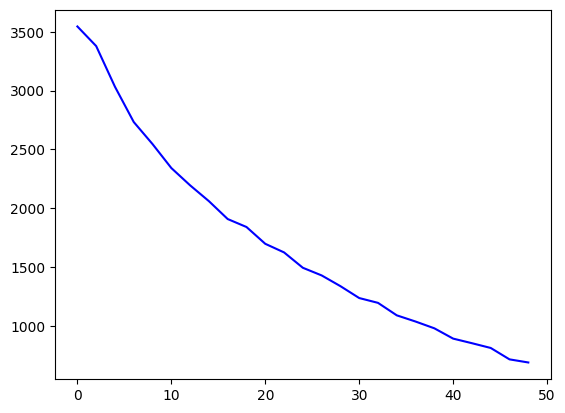

In [16]:
data_path = settings.save_dir / "experiment_0022/data.json"

with open(data_path, "r") as f:
    data_dict = json.load(f)

re = np.array(data_dict["I_data"], dtype=float) * 1e6
periods = np.array(data_dict["sweep_axis"], dtype=float)
c02signal = re[:, 0]
plt.plot(periods, c02signal, label='c2=0.1', color='blue')

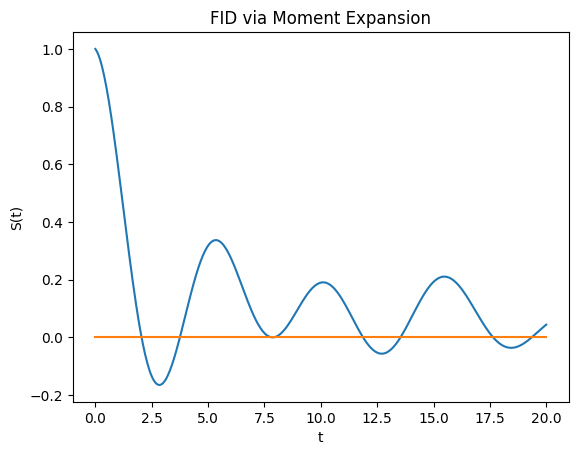

In [14]:
def fid_moment_expansion(t, moments):
    """
    Compute FID using moment expansion.

    Parameters:
    - t: array of time points
    - moments: list like [M0, M2, M4, ..., M_{2N}]
               where M0 should be 1

    Returns:
    - S(t): array
    """
    t = np.asarray(t)
    S = np.zeros_like(t, dtype=float)

    for n, M in enumerate(moments):
        order = 2 * n
        S = S + ((-1)**n) * M * t**order

    return np.array(S)


# ---- User control section ----

t = np.linspace(0, 20, 400)

S = fid_moment_expansion(t, moments)

# ---- Plot ----
plt.figure()
plt.plot(t, (S+1)*np.exp(-t/10))
plt.plot(t,np.zeros_like(t), label='Baseline')
plt.xlabel("t")
plt.ylabel("S(t)")
plt.title("FID via Moment Expansion")
plt.show()

A=1.042, alpha=0.105, tau=33.107, b=-0.042


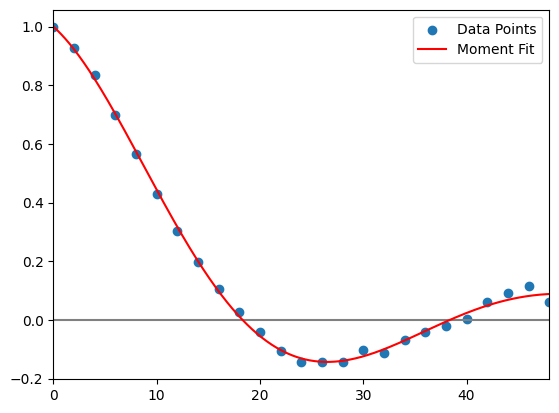

In [15]:
# ---- Your fit function ----
def damped_moment(t, A, alpha, tau, b):
    fid = A * (fid_moment_expansion(alpha * t, moments) + 1) * np.exp(-t / tau) + b
    return np.array(fid, dtype=float)


# ---- Load your data ----
data_path = settings.save_dir / "experiment_0033/data.json"

with open(data_path, "r") as f:
    data_dict = json.load(f)

re = np.array(data_dict["I_data"], dtype=float) * 1e6
periods = np.array(data_dict["sweep_axis"], dtype=float)
signal = re[:, 0] / c02signal


# ---- Fit ----
popt, pcov = curve_fit(damped_moment, periods, signal, p0=[1.0, 0.2, 10, 0], 
                       bounds=([0.5, 0.0, 0, -1.0], [2.0, 1.5, 50, 1.0]), maxfev=10000)


# ---- Plot ----
x_fit = np.linspace(min(periods), max(periods), 500)
y_fit = fid_moment_expansion(x_fit, moments)
y_fit = damped_moment(x_fit, *popt)

plt.plot(periods,np.zeros_like(periods), color='gray')
plt.scatter(periods, signal, label='Data Points')
plt.plot(x_fit, y_fit, color='red', label='Moment Fit')
plt.legend()
plt.xlim(0, max(periods))

print(f"A={popt[0]:.3f}, alpha={popt[1]:.3f}, tau={popt[2]:.3f}, b={popt[3]:.3f}")

Exp 16 | c2=1.0 | A=1.062, alpha=0.251, tau=16.854, b=-0.050
Exp 17 | c2=0.8 | A=1.075, alpha=0.201, tau=18.718, b=-0.052
Exp 18 | c2=0.6 | A=1.068, alpha=0.154, tau=23.524, b=-0.050
Exp 19 | c2=0.4 | A=1.033, alpha=0.105, tau=32.009, b=-0.030
Exp 20 | c2=0.2 | A=1.083, alpha=0.049, tau=41.085, b=-0.072
Exp 21 | c2=0.0 | A=1.000, alpha=0.603, tau=5.000, b=0.844


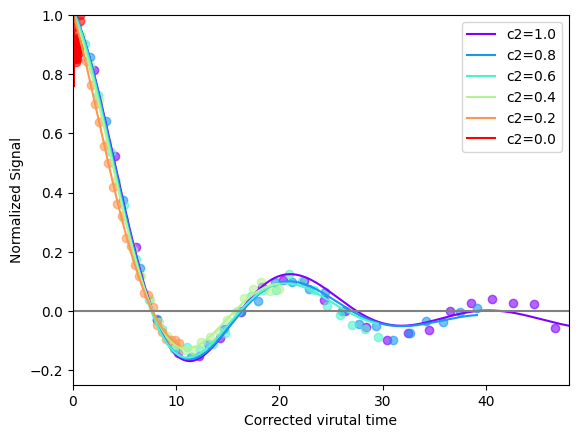

In [17]:
# ---- Your fit function ----
def damped_moment(t, A, alpha, tau, b):
    fid = A * (fid_moment_expansion(alpha * t, moments) + 1) * np.exp(-t / tau) + b
    return np.array(fid, dtype=float)

# ---- Experiment range ----
exp_ids = list(range(16, 22))  # 16 through 23
c2_values = -1 * np.arange(-1.0, 0.2, 0.2)  # -1.0 to 0.2

# ---- Colors (red → purple) ----
colors = plt.cm.rainbow(np.linspace(0, 1, len(exp_ids)))

plt.figure()

# ---- Loop over experiments ----
for i, exp_id in enumerate(exp_ids):
    data_path = settings.save_dir / f"experiment_{exp_id:04d}/data.json"

    with open(data_path, "r") as f:
        data_dict = json.load(f)

    re = np.array(data_dict["I_data"], dtype=float) * 1e6
    periods = np.array(data_dict["sweep_axis"], dtype=float)
    signal = re[:, 0] / c02signal

    # ---- Fit ----
    popt, _ = curve_fit(
        damped_moment,
        periods,
        signal,
        p0=[1.0, 0.2, 10, 0],
        bounds=([1.0, 0.0, 5, -1.0], [2.0, 0.7, 100.0, 1.0])
    )

    # ---- Fit curve ----
    x_fit = np.linspace(min(periods), max(periods), 500)
    y_fit = damped_moment(x_fit, *popt)

    # ---- Plot ----
    label = f"c2={c2_values[i]:.1f}"
    plt.scatter(abs(c2_values[i]+0.015) * periods, signal, color=colors[i], alpha=0.6)
    plt.plot(abs(c2_values[i]+0.015) * x_fit, y_fit, color=colors[i], label=label)

    print(f"Exp {exp_id} | c2={c2_values[i]:.1f} | "
          f"A={popt[0]:.3f}, alpha={popt[1]:.3f}, tau={popt[2]:.3f}, b={popt[3]:.3f}")

# ---- Final plot formatting ----
plt.plot(periods, np.zeros_like(periods), color='gray')  # baseline
plt.legend()
plt.xlim(0, max(periods))
plt.ylim(-.25, 1)
plt.xlabel("Corrected virutal time")
plt.ylabel("Normalized Signal")

plt.show()

# PyAmares

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from lmfit import Parameters
from pyAMARES.kernel.fid import simulate_fid, uninterleave

#!pip install pyAMARES
#!pip install lmfit

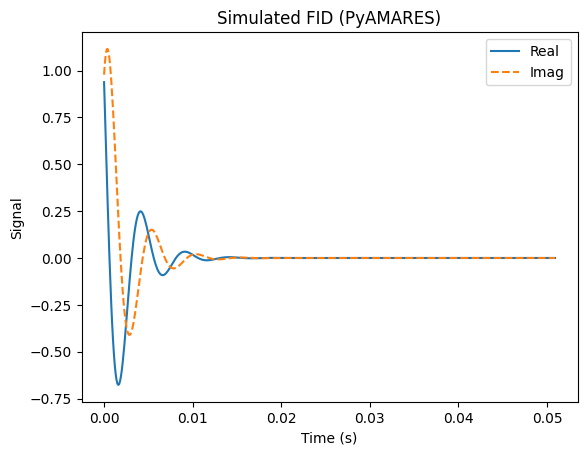

In [21]:
# --- 1. Define parameters ---
params = Parameters()

params.add('ak_1', value=1.0)       # amplitude
params.add('freq_1', value=100.0)   # frequency (Hz)
params.add('dk_1', value=200)       # damping (Lorentzian)
params.add('phi_1', value=0)      # phase
params.add('gk_1', value=0)       # Gaussian broadening (THIS WAS MISSING)

# --- 2. Simulate ---
fid = simulate_fid(
    params,
    MHz=282.19,
    sw=10000,
    fid_len=1020,
    snr_target=np.inf
)

fid_complex = uninterleave(fid)

# --- 3. Time axis ---
sw = 10000.0
t = np.arange(len(fid_complex)) / sw

# --- 4. Plot ---
plt.figure()
plt.plot(t, np.real(fid_complex), label='Real')
plt.plot(t, np.imag(fid_complex), '--', label='Imag')
plt.xlabel('Time (s)')
plt.ylabel('Signal')
plt.title('Simulated FID (PyAMARES)')
plt.legend()
plt.show()